<a href="https://colab.research.google.com/github/UIUC-CS445-DeepFakes/CNN/blob/main/CNN_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader


In [2]:

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!ls "/content/drive/MyDrive/CS445 Final Project/Data/" #You muct create a shortcut CS445 project in MyDrive


 CELEBDF       CROPPED_IMAGES.zip   UADFV
 CELEBDF.zip  'HUMAN FACES.zip'     UADFV.zip


In [4]:
!unzip "/content/drive/MyDrive/CS445 Final Project/Data/UADFV.zip" \
"UADFV/fake/frames/*" \
-d "/content/drive/MyDrive/CS445 Final Project/Data/"

Archive:  /content/drive/MyDrive/CS445 Final Project/Data/UADFV.zip
replace /content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/000.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/000.png  
replace /content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/009.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/009.png  
replace /content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/018.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/018.png  
replace /content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/028.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/028.png  
repl

In [ ]:
#!unzip "/content/drive/MyDrive/CS445 Final Project/Data/CELEBDF.zip" \
#-d "/content/drive/MyDrive/CS445 Final Project/Data/CELEBDF" # too large

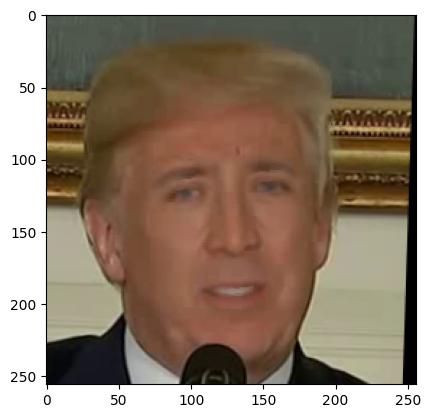

In [24]:
img_path = "/content/drive/MyDrive/CS445 Final Project/Data/UADFV/fake/frames/0000_fake/000.png"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.show()

In [ ]:
class VGG16(nn.Module):
  def __init__(self, input_channel, num_classes):
    super(VGG16, self).__init__()

    #5 blocks needed: Conv ->ReLU-> Conv->ReLU->MaxPool
    self.features = nn.Sequential(

        #64: 3 rgb to 64 channels
        nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)

        #128
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)

        #256
        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)

        #512
        nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)


        #512
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential()

    def forward(self, x):
      return x

In [ ]:
vgg16 = VGG16()